<a href="https://colab.research.google.com/github/Pushpesh987/Airport-parking-project/blob/master/ames_housing_all_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Libraries

In [ ]:
import pandas as pd
#Create Dataset
data = {
    "Study_Hours":[2, 4, 6, 8, 10]
}

# 🏠 Ames Housing — EDA, Regression & Classification

This notebook demonstrates a complete ML pipeline using the **Ames Housing dataset** from Kaggle.

**Supervised Learning Models covered:**
- **Regression** (predicting exact SalePrice): Linear Regression, Random Forest
- **Classification** (predicting price category): Logistic Regression, K-Nearest Neighbours, Decision Tree

**Un-Supervised Learning Models covered:**
- K-Means Clustering

Dataset is been picked from the kaggle

[link text](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

# **Data fields**
Here's a brief version of what you'll find in the data description file.

**SalePrice** - the property's sale price in dollars. This is the target variable that you're trying to predict.

**MSSubClass**: The building class

**MSZoning**: The general zoning classification

**LotFrontage**: Linear feet of street connected to property

**LotArea**: Lot size in square feet

**Street**: Type of road **access**

**Alley**: Type of alley access

**LotShape**: General shape of property

**LandContour**: Flatness of the property

**Utilities**: Type of utilities available

**LotConfig**: Lot configuration

**LandSlope**: Slope of property

**Neighborhood**: Physical locations within Ames city limits

**Condition1**: Proximity to main road or railroad

**Condition2**: Proximity to main road or railroad (if a second is present)

**BldgType**: Type of dwelling

**HouseStyle**: Style of dwelling

**OverallQual**: Overall material and finish quality

**OverallCond**: Overall condition rating

**YearBuilt**: Original construction date

**YearRemodAdd**: Remodel date

**RoofStyle**: Type of roof

**RoofMatl**: Roof material

**Exterior1st**: Exterior covering on house

**Exterior2nd**: Exterior covering on house (if more than one material)

**MasVnrType**: Masonry veneer type

**MasVnrArea**: Masonry veneer area in square feet

**ExterQual**: Exterior material quality

**ExterCond**: Present condition of the material on the exterior

**Foundation**: Type of foundation

**BsmtQual**: Height of the basement

**BsmtCond**: General condition of the basement

**BsmtExposure**: Walkout or garden level basement walls

**BsmtFinType1**: Quality of basement finished area

**BsmtFinSF1**: Type 1 finished square feet

**BsmtFinType2**: Quality of second finished area (if present)

**BsmtFinSF2**: Type 2 finished square feet

**BsmtUnfSF**: Unfinished square feet of basement area

**TotalBsmtSF**: Total square feet of basement area

**Heating**: Type of heating

**HeatingQC**: Heating quality and condition

**CentralAir**: Central air conditioning

**Electrical**: Electrical system

**1stFlrSF**: First Floor square feet

**2ndFlrSF**: Second floor square feet

**LowQualFinSF**: Low quality finished square feet (all floors)

**GrLivArea**: Above grade (ground) living area square feet

**BsmtFullBath**: Basement full bathrooms

**BsmtHalfBath**: Basement half bathrooms

**FullBath**: Full bathrooms above grade

**HalfBath**: Half baths above grade

**Bedroom**: Number of bedrooms above basement level

**Kitchen**: Number of kitchens

**KitchenQual**: Kitchen quality

**TotRmsAbvGrd**: Total rooms above grade (does not include bathrooms)

**Functional**: Home functionality rating

**Fireplaces**: Number of fireplaces

**FireplaceQu**: Fireplace quality

**GarageType**: Garage location

**GarageYrBlt**: Year garage was built

**GarageFinish**: Interior finish of the garage

**GarageCars**: Size of garage in car capacity

**GarageArea**: Size of garage in square feet

**GarageQual**: Garage quality

**GarageCond**: Garage condition

**PavedDrive**: Paved driveway

**WoodDeckSF**: Wood deck area in square feet

**OpenPorchSF**: Open porch area in square feet

**EnclosedPorch**: Enclosed porch area in square feet

**3SsnPorch**: Three season porch area in square feet

**ScreenPorch**: Screen porch area in square feet

**PoolArea**: Pool area in square feet

**PoolQC**: Pool quality

**Fence**: Fence quality

**MiscFeature**: Miscellaneous feature not covered in other categories

**MiscVal**: $Value of miscellaneous feature

**MoSold**: Month Sold

**YrSold**: Year Sold

**SaleType**: Type of sale

**SaleCondition**: Condition of sale

In [ ]:
# from google.colab import files
# uploaded = files.upload()

In [ ]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully!')

All libraries loaded successfully!


# 2. Load the Dataset

In [ ]:
data = pd.read_csv('train.csv')
print(f'Dataset shape: {data.shape}')

print(data.shape)
print(f'Number of features: {data.shape[1] - 1}')
print(f'Number of samples: {data.shape[0]}')

Dataset shape: (1460, 81)
(1460, 81)
Number of features: 80
Number of samples: 1460


# 3. Sanity Check

In [ ]:
# First 5 rows
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
data.sample(n=10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1393,1394,190,RM,60.0,10800,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Normal,163000
1268,1269,50,RL,NaN,14100,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,5,2008,WD,Normal,381000
277,278,20,RL,140.0,19138,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,141000
1114,1115,20,RL,90.0,5400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2006,WD,Normal,117000
264,265,30,RM,30.0,5232,Pave,Grvl,IR3,Bnk,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,73000
486,487,20,RL,79.0,10289,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,156000
17,18,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
1076,1077,50,RL,60.0,10800,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,4,2006,WD,Normal,170000
1225,1226,80,RL,65.0,10482,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnWw,NaN,0,6,2007,WD,Normal,145000
169,170,20,RL,NaN,16669,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2006,WD,Normal,228000


In [ ]:
# Data types and null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
# Descriptive statistics for numerical columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [ ]:
# Check missing values
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'Columns with missing values: {len(missing)}')
print()
print(missing)

Columns with missing values: 19

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


# 4. Exploratory Data Analysis (EDA)

## 4.1 Target Variable — SalePrice Distribution

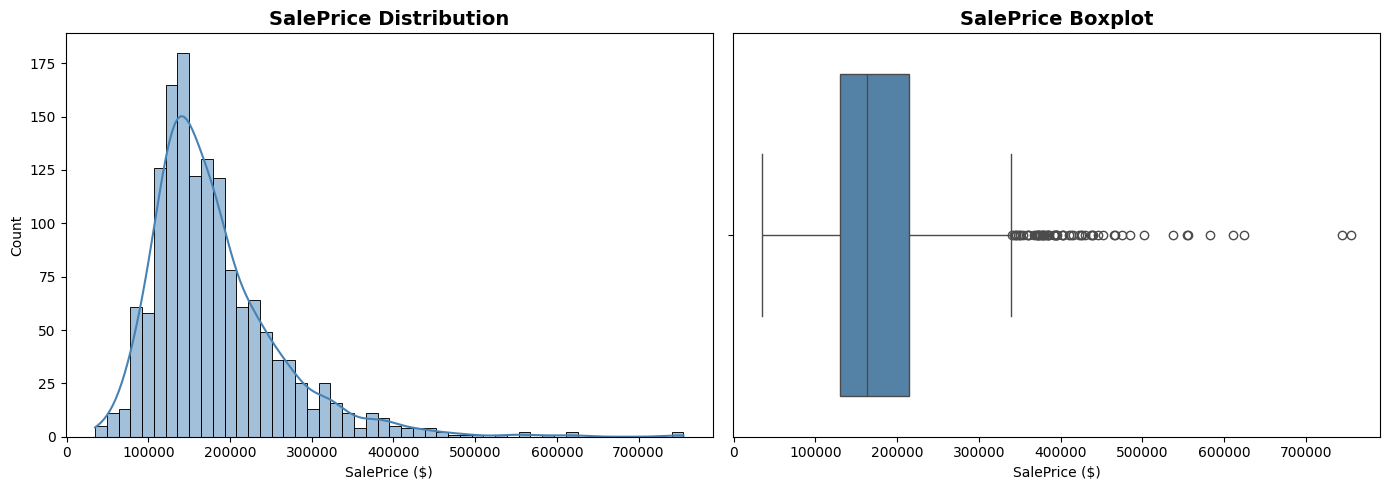

Mean Price   : $180,921
Median Price : $163,000
Min Price    : $34,900
Max Price    : $755,000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(data['SalePrice'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('SalePrice ($)')

# Boxplot
sns.boxplot(x=data['SalePrice'], ax=axes[1], color='steelblue')
axes[1].set_title('SalePrice Boxplot', fontsize=14, fontweight='bold')
axes[1].set_xlabel('SalePrice ($)')

plt.tight_layout()
plt.show()

print(f"Mean Price   : ${data['SalePrice'].mean():,.0f}")
print(f"Median Price : ${data['SalePrice'].median():,.0f}")
print(f"Min Price    : ${data['SalePrice'].min():,.0f}")
print(f"Max Price    : ${data['SalePrice'].max():,.0f}")

## 4.2 Correlation Heatmap (Top Features)

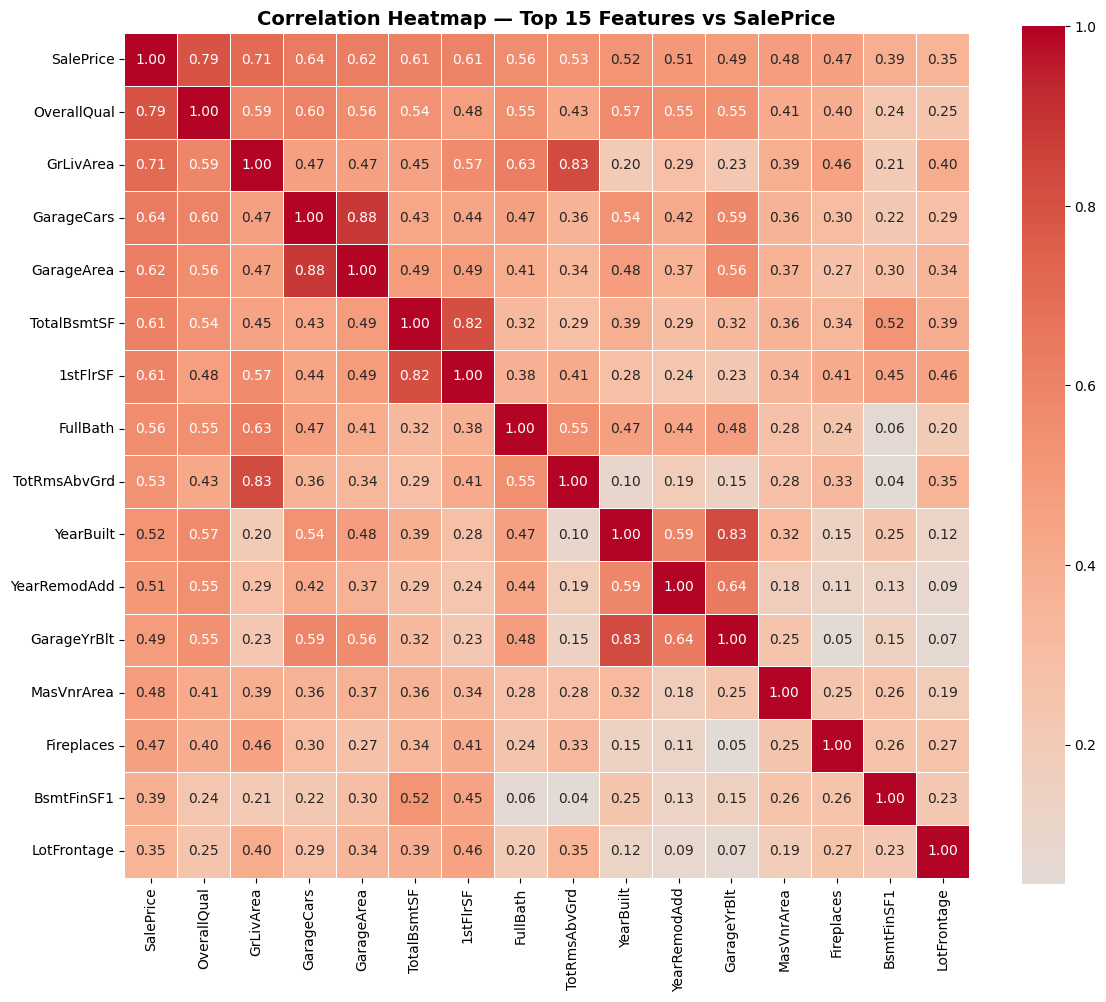


Top 15 features correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799


In [ ]:
# Find top 15 features most correlated with SalePrice
numeric_data = data.select_dtypes(include=[np.number])
correlations = numeric_data.corr()['SalePrice'].abs().sort_values(ascending=False)
top_features = correlations.head(16).index.tolist()  # top 15 + SalePrice itself

plt.figure(figsize=(12, 10))
sns.heatmap(data[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Top 15 Features vs SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 15 features correlated with SalePrice:')
print(correlations.head(16).to_string())

## 4.3 Key Feature vs SalePrice Scatter Plots

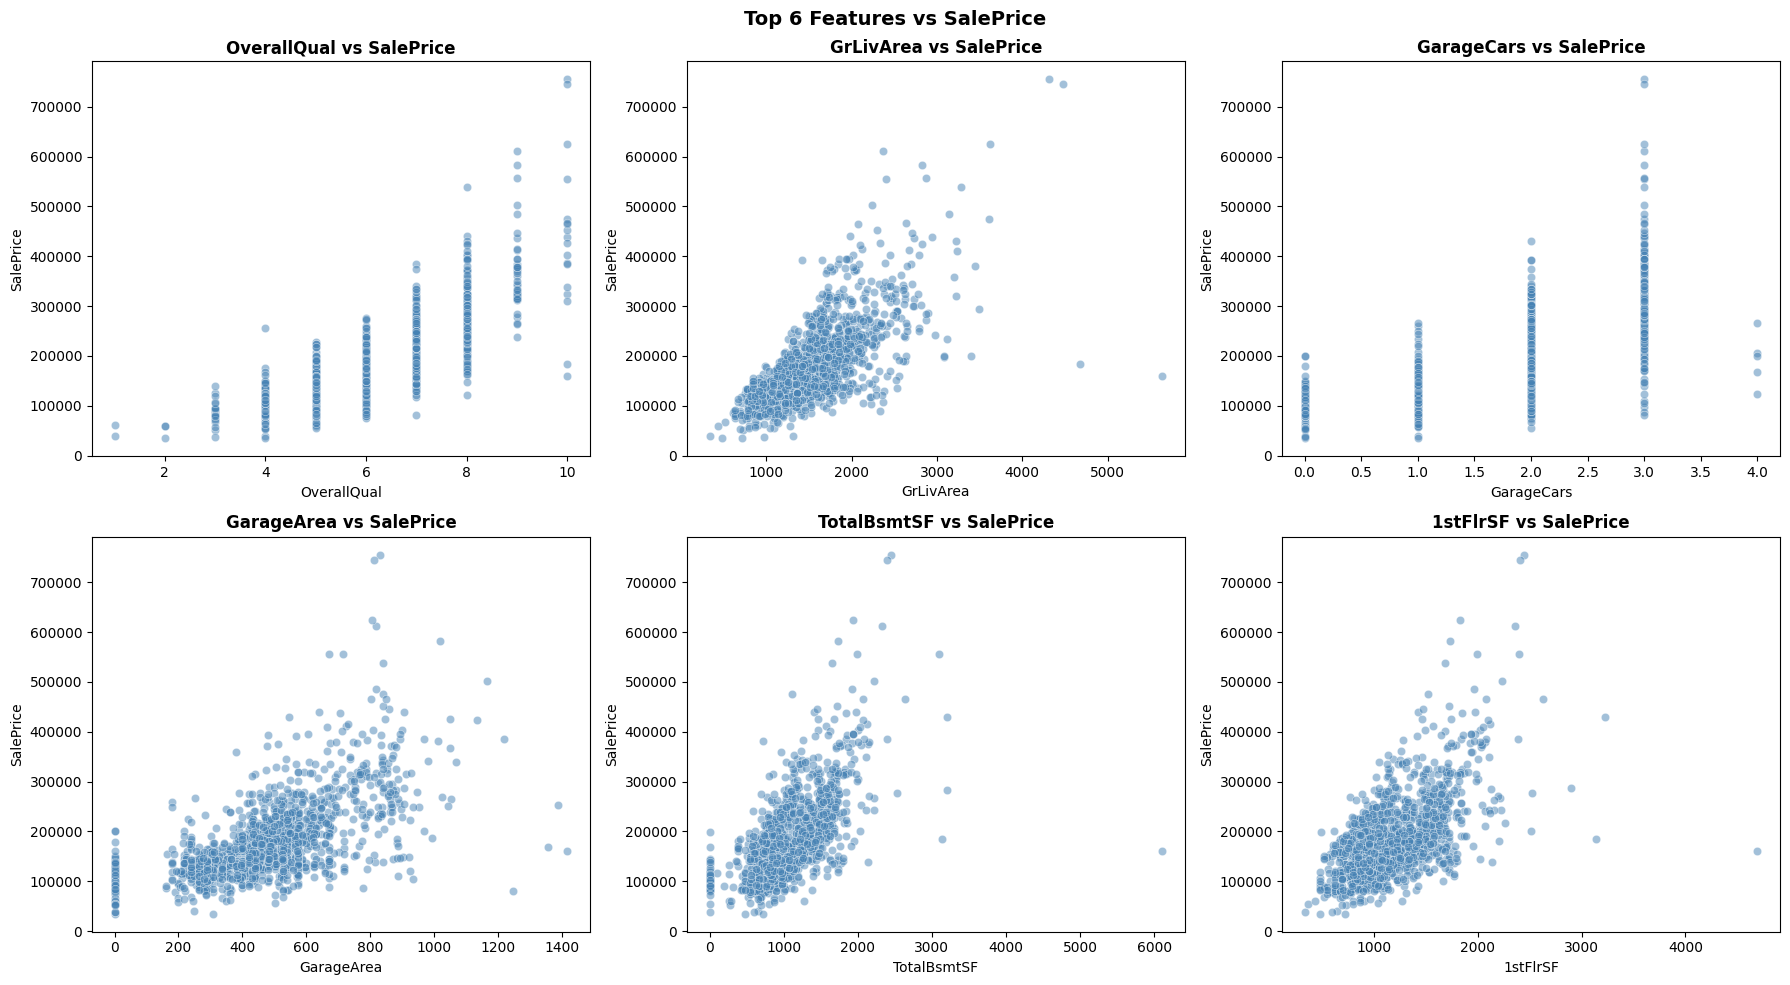

In [ ]:
# Scatter plots for top 6 numeric features
top_6 = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, feat in enumerate(top_6):
    row, col = idx // 3, idx % 3
    sns.scatterplot(data=data, x=feat, y='SalePrice', ax=axes[row][col], alpha=0.5, color='steelblue')
    axes[row][col].set_title(f'{feat} vs SalePrice', fontsize=12, fontweight='bold')

fig.suptitle('Top 6 Features vs SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.4 SalePrice by Neighborhood

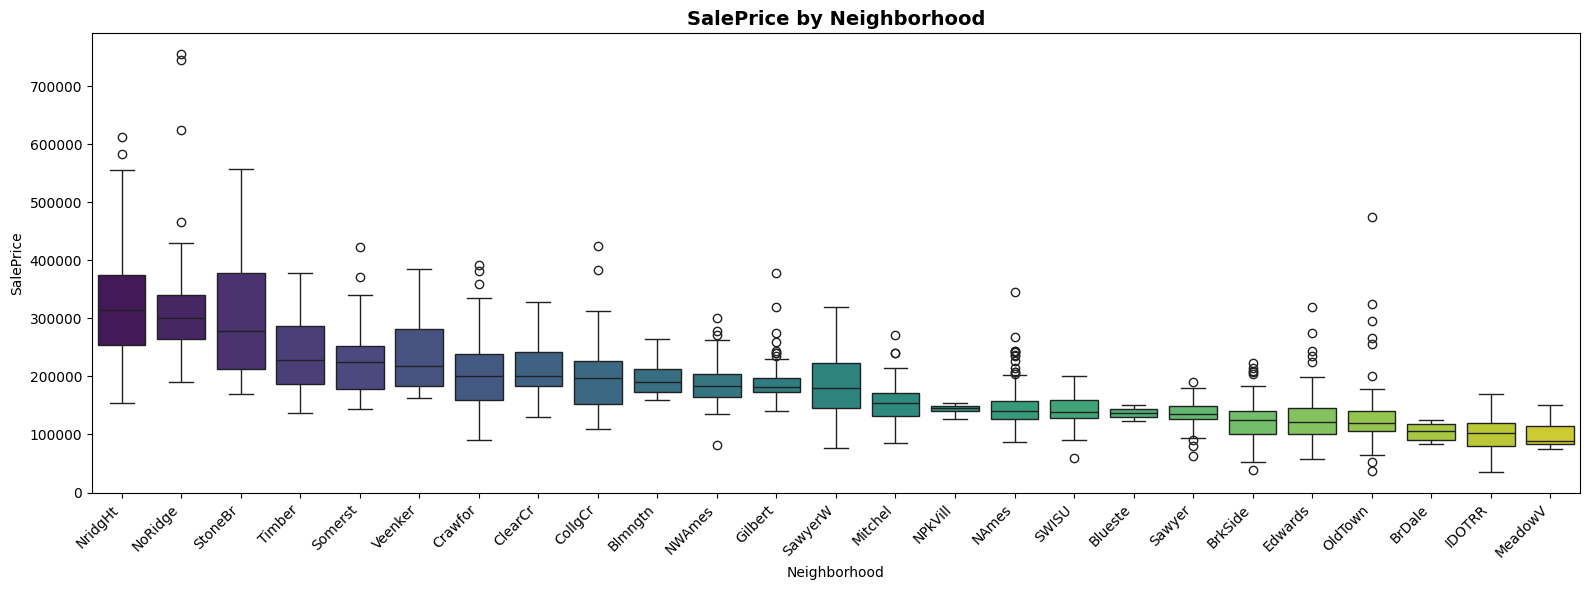

In [ ]:
plt.figure(figsize=(16, 6))
order = data.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
sns.boxplot(data=data, x='Neighborhood', y='SalePrice', order=order, palette='viridis')
plt.title('SalePrice by Neighborhood', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4.5 SalePrice by Overall Quality

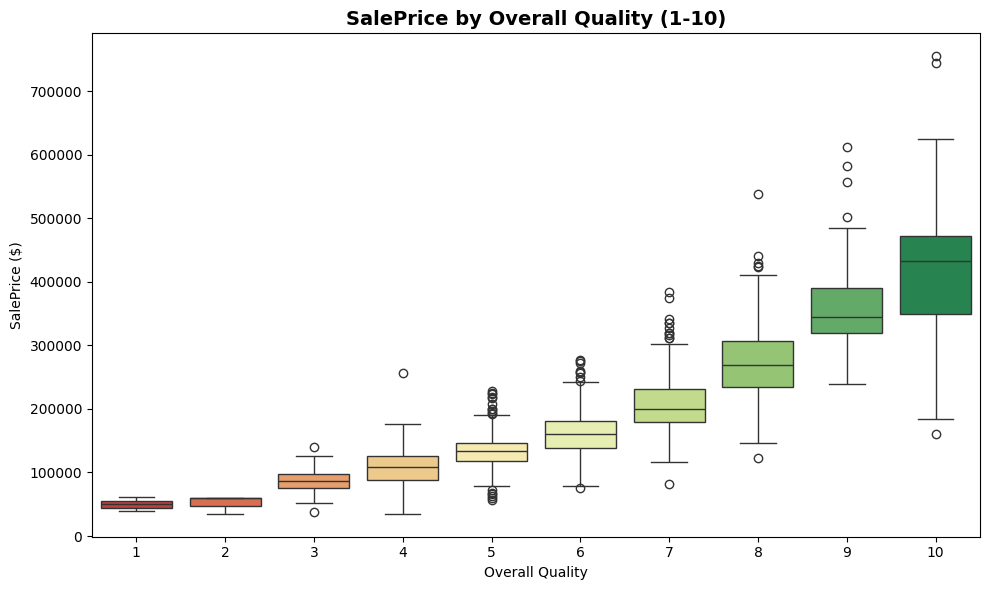

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='OverallQual', y='SalePrice', palette='RdYlGn')
plt.title('SalePrice by Overall Quality (1-10)', fontsize=14, fontweight='bold')
plt.xlabel('Overall Quality')
plt.ylabel('SalePrice ($)')
plt.tight_layout()
plt.show()

---
# PART A: REGRESSION MODELS
**Goal:** Predict the exact SalePrice (continuous value)

# 5. Prepare Data for Regression

In [ ]:
# Drop Id column (not a feature)
df = data.drop(columns=['Id'])

# Separate features and target
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical features  : {len(numerical_cols)}')
print(f'Categorical features: {len(categorical_cols)}')
print(f'Total features      : {len(numerical_cols) + len(categorical_cols)}')
print(f'\nNumerical: {numerical_cols}')
print(f'\nCategorical: {categorical_cols}')

Numerical features  : 36
Categorical features: 43
Total features      : 79

Numerical: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Categorical: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical

In [ ]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set    : {X_test.shape[0]} samples')

Training set: 1168 samples
Test set    : 292 samples


# 6. Build the Preprocessing Pipeline

In [ ]:
# Numerical pipeline: fill missing values with median, then scale
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Categorical pipeline: fill missing with 'Missing', then one-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Combine both into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols),
    ]
)

print('Preprocessor built!')
print(f'  Numerical  → SimpleImputer(median) → StandardScaler')
print(f'  Categorical → SimpleImputer(constant) → OneHotEncoder')

Preprocessor built!
  Numerical  → SimpleImputer(median) → StandardScaler
  Categorical → SimpleImputer(constant) → OneHotEncoder


# 7. Linear Regression

In [ ]:
# # Build pipeline
# lr_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('regressor', LinearRegression()),
# ])

# # Train
# lr_pipeline.fit(X_train, y_train)

# # Predict
# y_pred_lr = lr_pipeline.predict(X_test)

# # Evaluate
# rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
# r2_lr = r2_score(y_test, y_pred_lr)

# print('Linear Regression Results:')
# print(f'  RMSE      : ${rmse_lr:,.2f}')
# print(f'  R-squared : {r2_lr:.4f}')

from joblib import dump

# Build pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression()),
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr = lr_pipeline.predict(X_test)

# Evaluate
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"RMSE      : ${rmse_lr:,.2f}")
print(f"R-squared : {r2_lr:.4f}")

# ===========================
# Save the trained pipeline
# ===========================
dump(lr_pipeline, "linear_regression_model.pkl")

print("Model saved successfully as 'linear_regression_model.pkl'")

Linear Regression Results:
RMSE      : $65,385.32
R-squared : 0.4426
Model saved successfully as 'linear_regression_model.pkl'


# 8. Random Forest Regression

In [ ]:
# Build pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42)),
])

# Train
rf_pipeline.fit(X_train, y_train)

# Predict
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print('Random Forest Regression Results:')
print(f'  RMSE      : ${rmse_rf:,.2f}')
print(f'  R-squared : {r2_rf:.4f}')

Random Forest Regression Results:
  RMSE      : $29,171.43
  R-squared : 0.8891


# 10. Regression Model Comparison

In [ ]:
# Compare all regression models
reg_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE ($)': [rmse_lr, rmse_rf],
    'R-squared': [r2_lr, r2_rf],
}).set_index('Model').round(4)

print('=== REGRESSION MODEL COMPARISON ===')
print(reg_results.to_string())

=== REGRESSION MODEL COMPARISON ===
                     RMSE ($)  R-squared
Model                                   
Linear Regression  65385.3169     0.4426
Random Forest      29171.4275     0.8891


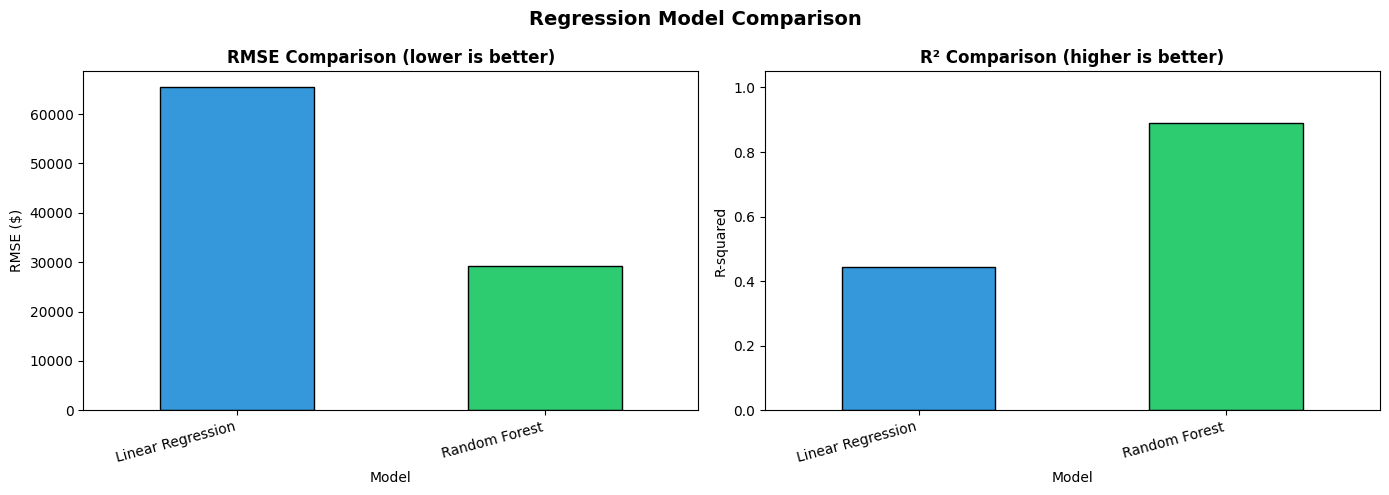

In [ ]:
# Visualize regression comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
reg_results['RMSE ($)'].plot(kind='bar', ax=axes[0], color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('RMSE Comparison (lower is better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE ($)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')

# R-squared comparison
reg_results['R-squared'].plot(kind='bar', ax=axes[1], color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('R² Comparison (higher is better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R-squared')
axes[1].set_ylim(0, 1.05)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')

fig.suptitle('Regression Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

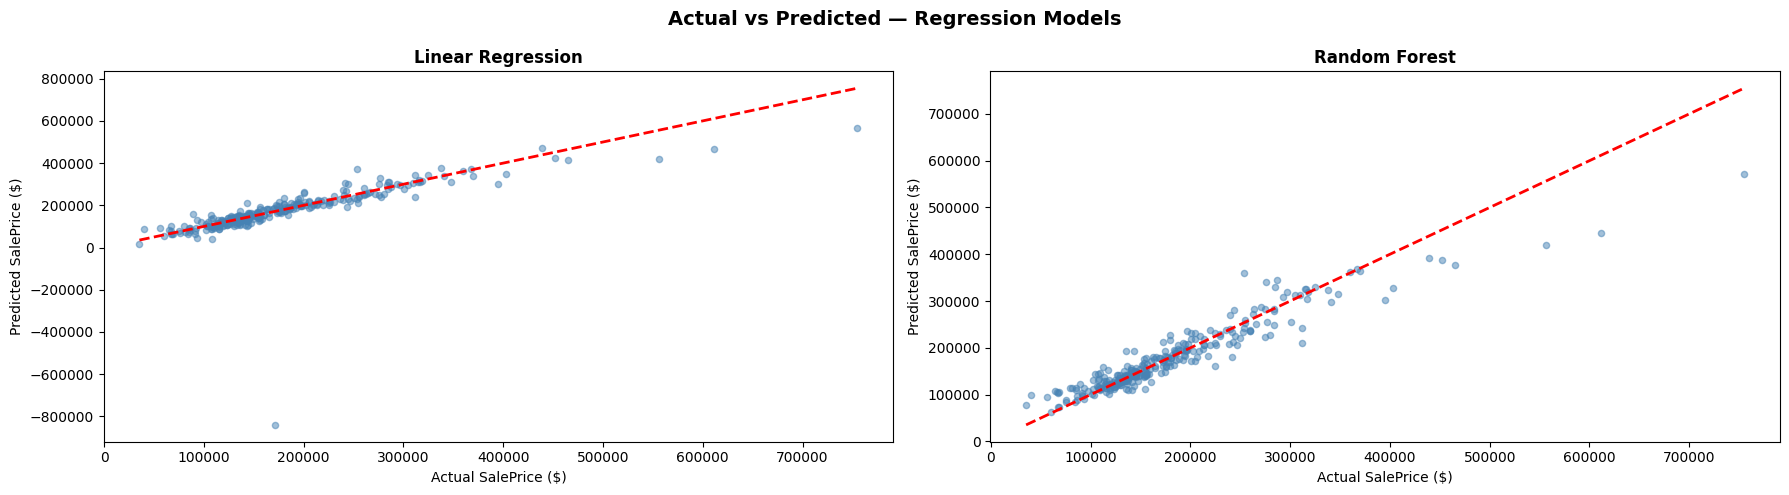

In [ ]:
# Actual vs Predicted plots for all 3 regression models
fig, axes = plt.subplots(1, 2,  figsize=(18, 5))

preds = {
    'Linear Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
}

for idx, (name, pred) in enumerate(preds.items()):
    axes[idx].scatter(y_test, pred, alpha=0.5, color='steelblue', s=20)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Actual SalePrice ($)')
    axes[idx].set_ylabel('Predicted SalePrice ($)')

fig.suptitle('Actual vs Predicted — Regression Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# PART B: CLASSIFICATION MODELS
**Goal:** Predict the price category (Low / Medium / High)

# 11. Convert Price to Categories

Price Category Distribution:
PriceCategory
Medium    490
Low       487
High      483
Name: count, dtype: int64

Price ranges per category:
  Low     : $    34,900 — $   139,600
  Medium  : $   139,900 — $   190,000
  High    : $   191,000 — $   755,000


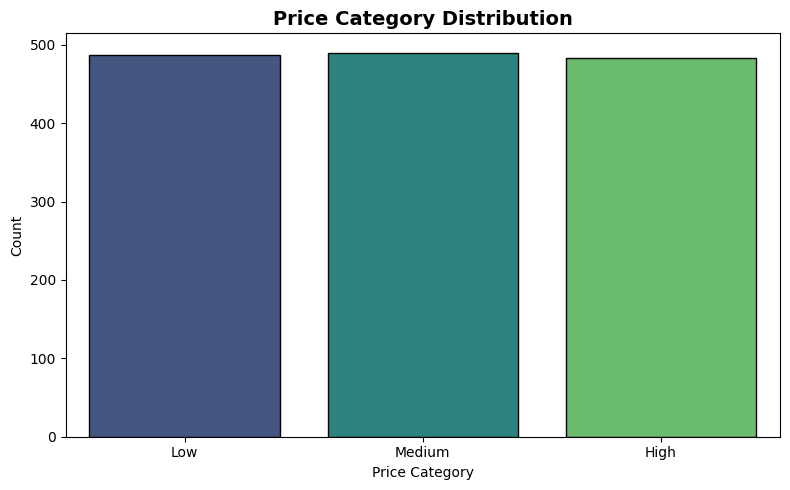

In [ ]:
# Convert SalePrice into 3 categories using quantile-based binning
# Low    = bottom 33% of prices
# Medium = middle 33% of prices
# High   = top 33% of prices

data['PriceCategory'] = pd.qcut(
    data['SalePrice'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print('Price Category Distribution:')
print(data['PriceCategory'].value_counts())

print(f'\nPrice ranges per category:')
for cat in ['Low', 'Medium', 'High']:
    subset = data[data['PriceCategory'] == cat]['SalePrice']
    print(f'  {cat:8s}: ${subset.min():>10,.0f} — ${subset.max():>10,.0f}')

# Visualize
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='PriceCategory', order=['Low', 'Medium', 'High'],
              palette='viridis', edgecolor='black')
plt.title('Price Category Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Price Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 12. Prepare Data for Classification

In [ ]:
# Features and target for classification
X_cls = data.drop(columns=['Id', 'SalePrice', 'PriceCategory'])
y_cls = data['PriceCategory']

# Same numerical and categorical columns as before
numerical_cols_cls = X_cls.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_cls = X_cls.select_dtypes(include=['object']).columns.tolist()

# Train-Test Split (stratified to keep class balance)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f'Training set: {X_train_cls.shape[0]} samples')
print(f'Test set    : {X_test_cls.shape[0]} samples')
print(f'\nClass distribution in test set:')
print(y_test_cls.value_counts())

Training set: 1168 samples
Test set    : 292 samples

Class distribution in test set:
PriceCategory
Medium    98
Low       97
High      97
Name: count, dtype: int64


In [ ]:
# Build preprocessor for classification (same structure)
num_pipeline_cls = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

cat_pipeline_cls = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor_cls = ColumnTransformer(
    transformers=[
        ('num', num_pipeline_cls, numerical_cols_cls),
        ('cat', cat_pipeline_cls, categorical_cols_cls),
    ]
)

print('Classification preprocessor built!')

Classification preprocessor built!


# 13. Logistic Regression

In [ ]:
# Build pipeline
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_cls),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)),
])

# Train
logistic_pipeline.fit(X_train_cls, y_train_cls)

# Predict
y_pred_logistic = logistic_pipeline.predict(X_test_cls)

# Evaluate
print('Logistic Regression Results:')
print(f'  Accuracy  : {accuracy_score(y_test_cls, y_pred_logistic):.4f}')
print(f'  Precision : {precision_score(y_test_cls, y_pred_logistic, average="weighted"):.4f}')
print(f'  Recall    : {recall_score(y_test_cls, y_pred_logistic, average="weighted"):.4f}')
print(f'  F1-Score  : {f1_score(y_test_cls, y_pred_logistic, average="weighted"):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test_cls, y_pred_logistic, target_names=['Low', 'Medium', 'High']))

Logistic Regression Results:
  Accuracy  : 0.7911
  Precision : 0.7931
  Recall    : 0.7911
  F1-Score  : 0.7914

Classification Report:
              precision    recall  f1-score   support

         Low       0.85      0.89      0.87        97
      Medium       0.84      0.77      0.81        97
        High       0.69      0.71      0.70        98

    accuracy                           0.79       292
   macro avg       0.79      0.79      0.79       292
weighted avg       0.79      0.79      0.79       292



# 14. K-Nearest Neighbours (KNN)

In [ ]:
# Build pipeline
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_cls),
    ('classifier', KNeighborsClassifier(n_neighbors=5)),
])

# Train
knn_pipeline.fit(X_train_cls, y_train_cls)

# Predict
y_pred_knn = knn_pipeline.predict(X_test_cls)

# Evaluate
print('K-Nearest Neighbours Results:')
print(f'  Accuracy  : {accuracy_score(y_test_cls, y_pred_knn):.4f}')
print(f'  Precision : {precision_score(y_test_cls, y_pred_knn, average="weighted"):.4f}')
print(f'  Recall    : {recall_score(y_test_cls, y_pred_knn, average="weighted"):.4f}')
print(f'  F1-Score  : {f1_score(y_test_cls, y_pred_knn, average="weighted"):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test_cls, y_pred_knn, target_names=['Low', 'Medium', 'High']))

K-Nearest Neighbours Results:
  Accuracy  : 0.7842
  Precision : 0.7797
  Recall    : 0.7842
  F1-Score  : 0.7798

Classification Report:
              precision    recall  f1-score   support

         Low       0.82      0.85      0.83        97
      Medium       0.81      0.90      0.85        97
        High       0.71      0.61      0.66        98

    accuracy                           0.78       292
   macro avg       0.78      0.78      0.78       292
weighted avg       0.78      0.78      0.78       292



# 15. Decision Tree

In [ ]:
# Build pipeline
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_cls),
    ('classifier', DecisionTreeClassifier(random_state=42)),
])

# Train
dt_pipeline.fit(X_train_cls, y_train_cls)

# Predict
y_pred_dt = dt_pipeline.predict(X_test_cls)

# Evaluate
print('Decision Tree Results:')
print(f'  Accuracy  : {accuracy_score(y_test_cls, y_pred_dt):.4f}')
print(f'  Precision : {precision_score(y_test_cls, y_pred_dt, average="weighted"):.4f}')
print(f'  Recall    : {recall_score(y_test_cls, y_pred_dt, average="weighted"):.4f}')
print(f'  F1-Score  : {f1_score(y_test_cls, y_pred_dt, average="weighted"):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test_cls, y_pred_dt, target_names=['Low', 'Medium', 'High']))

Decision Tree Results:
  Accuracy  : 0.7603
  Precision : 0.7608
  Recall    : 0.7603
  F1-Score  : 0.7603

Classification Report:
              precision    recall  f1-score   support

         Low       0.84      0.87      0.85        97
      Medium       0.79      0.75      0.77        97
        High       0.65      0.66      0.66        98

    accuracy                           0.76       292
   macro avg       0.76      0.76      0.76       292
weighted avg       0.76      0.76      0.76       292



# 16. Classification Model Comparison

In [ ]:
# Compare all classification models
cls_results = pd.DataFrame({
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test_cls, y_pred_logistic),
        'Precision': precision_score(y_test_cls, y_pred_logistic, average='weighted'),
        'Recall': recall_score(y_test_cls, y_pred_logistic, average='weighted'),
        'F1-Score': f1_score(y_test_cls, y_pred_logistic, average='weighted'),
    },
    'K-Nearest Neighbours': {
        'Accuracy': accuracy_score(y_test_cls, y_pred_knn),
        'Precision': precision_score(y_test_cls, y_pred_knn, average='weighted'),
        'Recall': recall_score(y_test_cls, y_pred_knn, average='weighted'),
        'F1-Score': f1_score(y_test_cls, y_pred_knn, average='weighted'),
    },
    'Decision Tree': {
        'Accuracy': accuracy_score(y_test_cls, y_pred_dt),
        'Precision': precision_score(y_test_cls, y_pred_dt, average='weighted'),
        'Recall': recall_score(y_test_cls, y_pred_dt, average='weighted'),
        'F1-Score': f1_score(y_test_cls, y_pred_dt, average='weighted'),
    },
}).T.round(4)

print('=== CLASSIFICATION MODEL COMPARISON ===')
print(cls_results.to_string())

=== CLASSIFICATION MODEL COMPARISON ===
                      Accuracy  Precision  Recall  F1-Score
Logistic Regression     0.7911     0.7931  0.7911    0.7914
K-Nearest Neighbours    0.7842     0.7797  0.7842    0.7798
Decision Tree           0.7603     0.7608  0.7603    0.7603


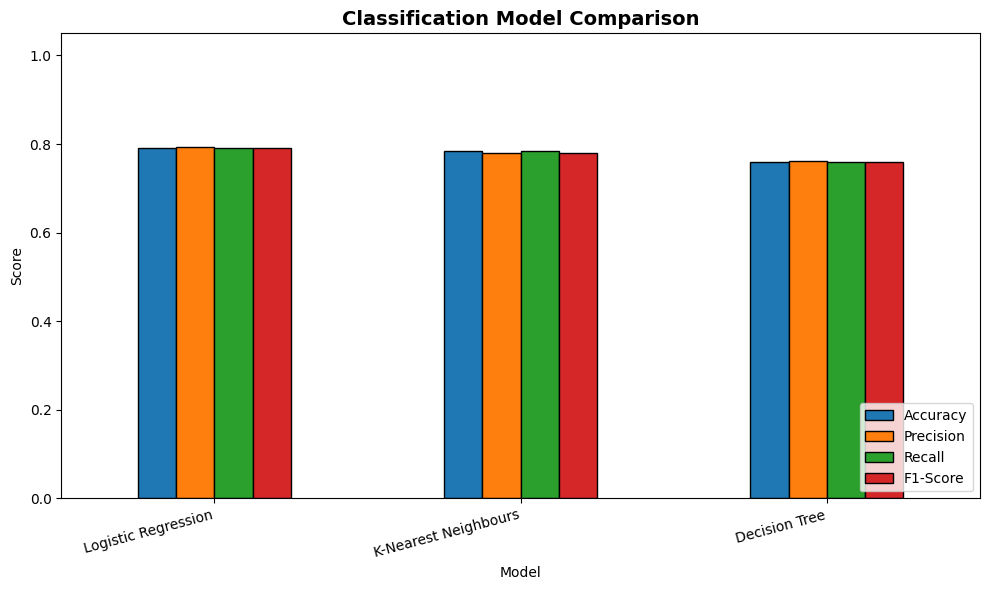

In [ ]:
# Bar chart comparing classification metrics
fig, ax = plt.subplots(figsize=(10, 6))
cls_results.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Classification Model Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.show()

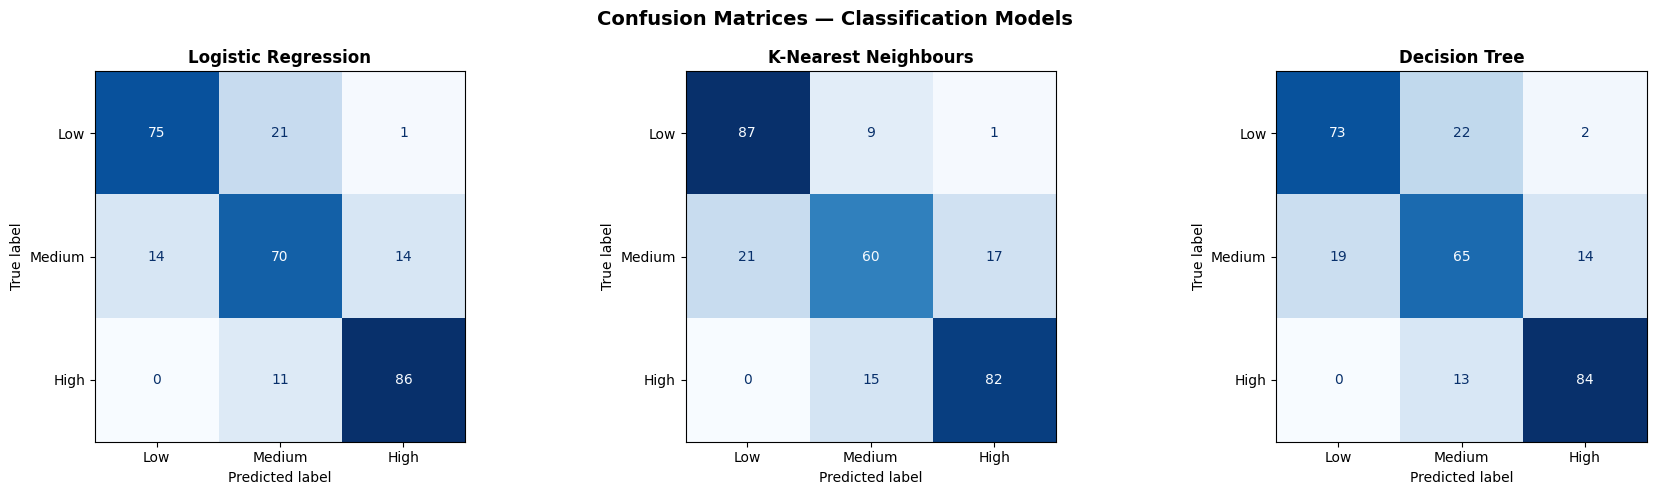

In [ ]:
# Confusion Matrices for all 3 classification models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cls_models = {
    'Logistic Regression': y_pred_logistic,
    'K-Nearest Neighbours': y_pred_knn,
    'Decision Tree': y_pred_dt,
}

for idx, (name, preds) in enumerate(cls_models.items()):
    cm = confusion_matrix(y_test_cls, preds, labels=['Low', 'Medium', 'High'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(name, fontsize=12, fontweight='bold')

fig.suptitle('Confusion Matrices — Classification Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 17. Final Summary — All 6 Models

In [ ]:
print('=' * 65)
print('FINAL SUMMARY — ALL 6 MODELS')
print('=' * 65)

print('\n--- REGRESSION MODELS (predicting exact price) ---')
print(f'{"Model":<25} {"RMSE ($)":>12} {"R-squared":>12}')
print('-' * 50)
print(f'{"Linear Regression":<25} {rmse_lr:>12,.0f} {r2_lr:>12.4f}')
print(f'{"Random Forest":<25} {rmse_rf:>12,.0f} {r2_rf:>12.4f}')

print('\n--- CLASSIFICATION MODELS (predicting Low/Medium/High) ---')
print(cls_results.to_string())

print('\n' + '=' * 65)
print('DONE!')
print('=' * 65)

FINAL SUMMARY — ALL 6 MODELS

--- REGRESSION MODELS (predicting exact price) ---
Model                         RMSE ($)    R-squared
--------------------------------------------------
Linear Regression               65,385       0.4426
Random Forest                   29,171       0.8891

--- CLASSIFICATION MODELS (predicting Low/Medium/High) ---
                      Accuracy  Precision  Recall  F1-Score
Logistic Regression     0.7911     0.7931  0.7911    0.7914
K-Nearest Neighbours    0.7842     0.7797  0.7842    0.7798
Decision Tree           0.7603     0.7608  0.7603    0.7603

DONE!
